# Imports

In [53]:
from functools import reduce

import gpytorch

from helpers.gp_classes import DataGPModel, ExactGPModel
from helpers.example_kernels import available
from helpers.plotting_functions import plot_training_data, plot_single_input_gp_posterior
from helpers.training_functions import granso_optimization
from helpers.util_functions import prior_distribution, extract_model_parameters

from laplace_model_selection.metrics import Lap0, LapAIC, LapBIC, AIC, BIC, NestedSampling, MLL, MAP

from math import ceil
import matplotlib.pyplot as plt

import numpy as np

import pandas as pd
from plotnine import (
    ggplot, aes, geom_col, geom_point, geom_text,
    coord_flip, labs, theme_minimal, theme, position_nudge, position_stack,
    scale_color_manual, scale_fill_manual
)

import torch
import tqdm
from typing import List

# Helper functions

In [54]:

def grid_of(plots: List[ggplot], ncol: int = 3):
    """
    Combine a list of ggplot objects into a grid using plotnine-0.15
    composition operators (| and /).

    Parameters
    ----------
    plots : list of ggplot
        The individual plots you created in a loop/comprehension.
    ncol : int, default 3
        Number of columns per row in the final figure.

    Returns
    -------
    ggplot
        A single composed plot that can be shown, saved, or further
        modified (e.g. + theme(figure_size=(...)) ).
    """
    if not plots:
        raise ValueError("Empty plot list")

    # --- 1. group into rows -----------------------------------------
    nrow  = ceil(len(plots) / ncol)
    rows  = [plots[i*ncol:(i+1)*ncol] for i in range(nrow)]

    # --- 2. reduce each row with `|` --------------------------------
    def hjoin(row):
        return reduce(lambda a, b: a | b, row) if len(row) > 1 else row[0]

    row_plots = list(map(hjoin, rows))

    # --- 3. stack the rows with `/` ---------------------------------
    grid = reduce(lambda a, b: a / b, row_plots) if len(row_plots) > 1 else row_plots[0]
    return grid


# Definitions

## Hold

In [55]:
hold = True

## Seed

In [56]:
use_seed = True
if use_seed:
    torch.manual_seed(42)

## Others

In [57]:
use_NS = False
non_gp_params_dict = torch.nn.ParameterDict()
# Default datatype
torch.set_default_dtype(torch.float64)

# Data

## Data helpers

In [58]:
def generate_x_1d(bounds, counts=None):
    if counts is None:
        n_points = 100
        for bound in bounds:
            if isinstance(bound, tuple):
                x = torch.linspace(bound[0], bound[1], n_points)
            else:
                x = torch.linspace(0, bound, n_points)
            yield x
    else:
        for bound, count in zip(bounds, counts):
            if isinstance(bound, tuple):
                x = torch.linspace(bound[0], bound[1], count)
            else:
                x = torch.linspace(0, bound, count)
            yield x

In [59]:
def z_score(x, mean, std):
    """
    Z-score normalization of a tensor x with given mean and std.
    
    Parameters
    ----------
    x : torch.Tensor
        The input tensor to normalize.
    mean : float
        The mean value for normalization.
    std : float
        The standard deviation for normalization.
    
    Returns
    -------
    torch.Tensor
        The normalized tensor.
    """
    return (x - mean) / std if std != 0 else x - mean

In [60]:
def section_wise_y_data(list_of_x, list_of_lambdas):
    for x, lambdas in zip(list_of_x, list_of_lambdas):
        yield lambdas(x)

In [61]:
index_put_param = lambda y, parameter, indice: y.index_put(indice, parameter, accumulate=True)
add_noise = lambda y, noise_level=0.1: y + noise_level * torch.randn_like(y)

linear_transformation = lambda y, a, b : a*y + b
cut_after_threshold = lambda y, threshold: torch.where(y > threshold, threshold, y)


y_ops = {
    "add noise": add_noise,
    "index put param": index_put_param,
    "linear transformation": linear_transformation,
    "cut after threshold": cut_after_threshold,
}

## Data

In [62]:
y_ops.keys()

dict_keys(['add noise', 'index put param', 'linear transformation', 'cut after threshold'])

In [63]:
#Parameters: {'f0_x_min': -7.108671188354492, 'f0_x_max': -8.615398406982422, 'f0_x_count': 60.2872200012207, 'f1_x_min': 2.052143096923828, 'f1_x_max': 8.088432312011719, 'f1_x_count': 69.02001953125}

num_periods = 0.25
x_bounds = [
    #(-round(num_periods*torch.pi, 2), round(num_periods*torch.pi, 2)),
    (-7.1, -8.6),
    (2.1, 8.1)
]
x_counts = [60, 69]

non_gp_params_dict.update(
    {"noise_1" : torch.nn.Parameter(torch.tensor(1.0, requires_grad=True))}
)

In [64]:
train_x = list(generate_x_1d(bounds=x_bounds, counts=x_counts))

# f(x) = 0 into f(x) = x^2
x_sq_steepness = 1.0 
lambdas = [lambda x: torch.zeros_like(x), lambda x: x_sq_steepness*x**2]
# Two areas for f(x)=0
#lambdas = [lambda x: torch.zeros_like(x), lambda x: torch.zeros_like(x), lambda x: x_sq_steepness*x**2]
# f(x) = sin(x)
#lambdas = [lambda x: torch.sin(x)]

train_y = list(section_wise_y_data(train_x, lambdas))
data_back = torch.stack([torch.cat(train_x), torch.cat(train_y)])
data = sorted(torch.stack([torch.cat(train_x), torch.cat(list(train_y))]).T, key=lambda x: x[0])
train_x = torch.tensor([d[0] for d in data])
train_y = torch.tensor([d[1] for d in data])

In [65]:
train_x

tensor([-8.6000, -8.5746, -8.5492, -8.5237, -8.4983, -8.4729, -8.4475, -8.4220,
        -8.3966, -8.3712, -8.3458, -8.3203, -8.2949, -8.2695, -8.2441, -8.2186,
        -8.1932, -8.1678, -8.1424, -8.1169, -8.0915, -8.0661, -8.0407, -8.0153,
        -7.9898, -7.9644, -7.9390, -7.9136, -7.8881, -7.8627, -7.8373, -7.8119,
        -7.7864, -7.7610, -7.7356, -7.7102, -7.6847, -7.6593, -7.6339, -7.6085,
        -7.5831, -7.5576, -7.5322, -7.5068, -7.4814, -7.4559, -7.4305, -7.4051,
        -7.3797, -7.3542, -7.3288, -7.3034, -7.2780, -7.2525, -7.2271, -7.2017,
        -7.1763, -7.1508, -7.1254, -7.1000,  2.1000,  2.1882,  2.2765,  2.3647,
         2.4529,  2.5412,  2.6294,  2.7176,  2.8059,  2.8941,  2.9824,  3.0706,
         3.1588,  3.2471,  3.3353,  3.4235,  3.5118,  3.6000,  3.6882,  3.7765,
         3.8647,  3.9529,  4.0412,  4.1294,  4.2176,  4.3059,  4.3941,  4.4824,
         4.5706,  4.6588,  4.7471,  4.8353,  4.9235,  5.0118,  5.1000,  5.1882,
         5.2765,  5.3647,  5.4529,  5.54

In [66]:
train_y

tensor([ 0.0000,  0.0000,  0.0000,  0.0000,  0.0000,  0.0000,  0.0000,  0.0000,
         0.0000,  0.0000,  0.0000,  0.0000,  0.0000,  0.0000,  0.0000,  0.0000,
         0.0000,  0.0000,  0.0000,  0.0000,  0.0000,  0.0000,  0.0000,  0.0000,
         0.0000,  0.0000,  0.0000,  0.0000,  0.0000,  0.0000,  0.0000,  0.0000,
         0.0000,  0.0000,  0.0000,  0.0000,  0.0000,  0.0000,  0.0000,  0.0000,
         0.0000,  0.0000,  0.0000,  0.0000,  0.0000,  0.0000,  0.0000,  0.0000,
         0.0000,  0.0000,  0.0000,  0.0000,  0.0000,  0.0000,  0.0000,  0.0000,
         0.0000,  0.0000,  0.0000,  0.0000,  4.4100,  4.7884,  5.1823,  5.5918,
         6.0169,  6.4576,  6.9138,  7.3856,  7.8730,  8.3759,  8.8944,  9.4285,
         9.9782, 10.5434, 11.1242, 11.7206, 12.3325, 12.9600, 13.6031, 14.2617,
        14.9360, 15.6257, 16.3311, 17.0520, 17.7885, 18.5406, 19.3083, 20.0915,
        20.8903, 21.7046, 22.5346, 23.3801, 24.2411, 25.1178, 26.0100, 26.9178,
        27.8411, 28.7801, 29.7346, 30.70

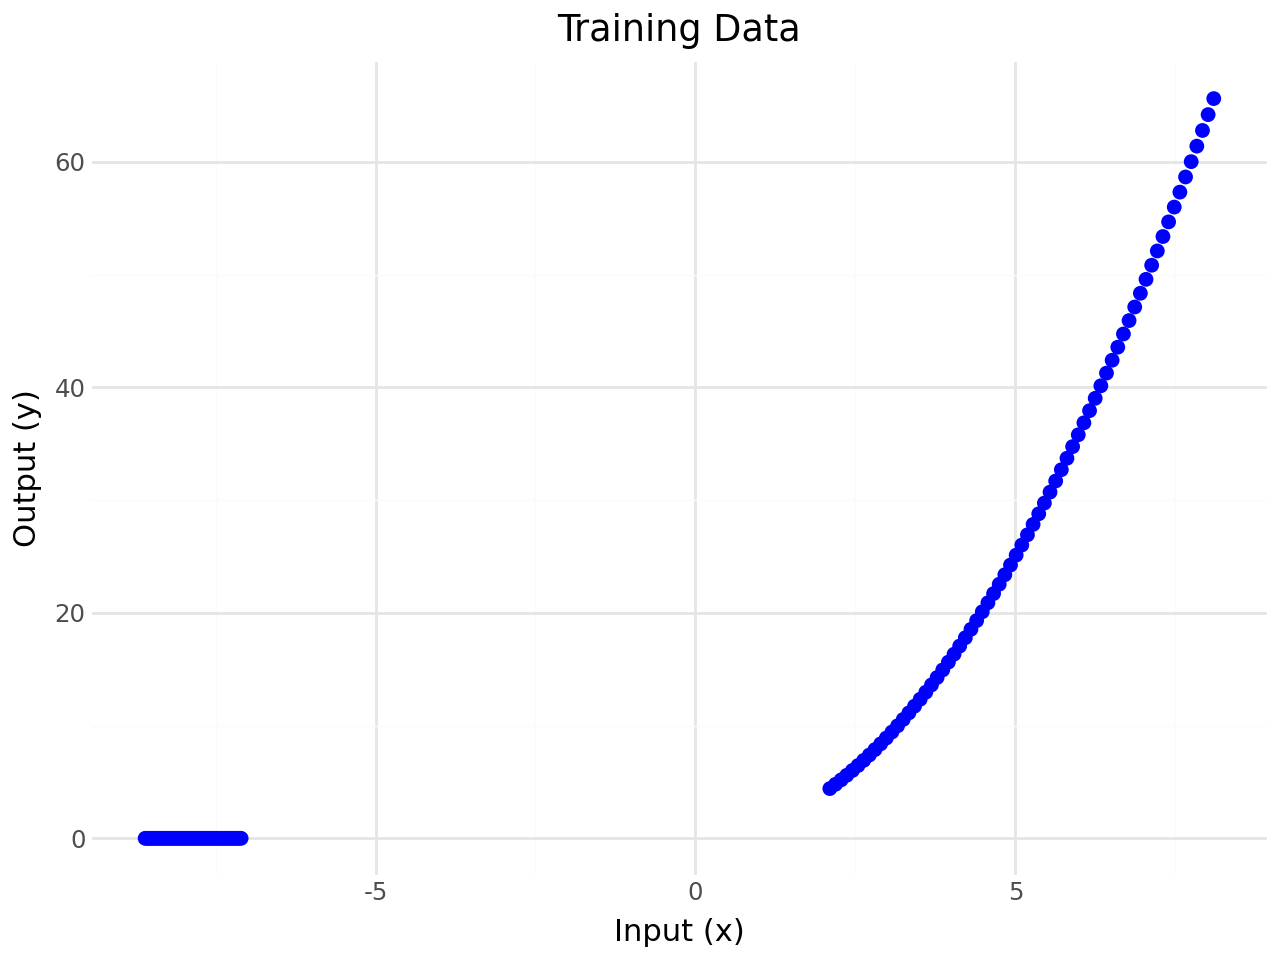

In [67]:
# ggplot that shows the training data
g = (
    ggplot(pd.DataFrame({"x": train_x.numpy(), "y": train_y.numpy()}), aes(x="x", y="y"))
    + geom_point(color="blue", size=2)
    + labs(title="Training Data", x="Input (x)", y="Output (y)")
    + theme_minimal()
)
g

# GP Definition

In [68]:
#available()

In [69]:
kernel_name = "MAT32"
#kernel_name = "SE"

likelihood_MLL = gpytorch.likelihoods.GaussianLikelihood()
model_MLL = ExactGPModel(train_x=train_x, train_y=train_y, likelihood=likelihood_MLL, kernel_name=kernel_name)

likelihood_MAP = gpytorch.likelihoods.GaussianLikelihood()
model_MAP = ExactGPModel(train_x=train_x, train_y=train_y, likelihood=likelihood_MAP, kernel_name=kernel_name)

# Training

In [70]:
neg_scaled_mll, model_MLL, likelihood_MLL, training_log_MLL = granso_optimization(model_MLL, likelihood_MLL, train_x, train_y, random_restarts=20, maxit=1000, MAP=False, double_precision=False, verbose=False)

model_parameter_prior = prior_distribution(model_MAP, param_specs=None, kernel_param_specs=None, default_mean=0.0, default_std=10.0)

neg_scaled_map, model_MAP, likelihood_MAP, training_log_MAP = granso_optimization(model_MAP, likelihood_MAP, train_x, train_y, random_restarts=20, maxit=1000, MAP=True, double_precision=False, verbose=False, model_parameter_prior=model_parameter_prior)

In [71]:
neg_scaled_map
neg_scaled_mll

tensor(4.6022, grad_fn=<NegBackward0>)

In [72]:
list(model_MLL.named_parameters())

[('likelihood.noise_covar.raw_noise',
  Parameter containing:
  tensor([536.7544], requires_grad=True)),
 ('covar_module.raw_lengthscale',
  Parameter containing:
  tensor([[12.9157]], requires_grad=True))]

In [73]:
list(model_MAP.named_parameters())

[('likelihood.noise_covar.raw_noise',
  Parameter containing:
  tensor([115.7704], requires_grad=True)),
 ('covar_module.raw_lengthscale',
  Parameter containing:
  tensor([[8.0371]], requires_grad=True))]

### Parameter replacement

In [74]:
from helpers.util_functions import reparameterize_model
#def reparameterize_model(model, theta):
    #for model_param, sampled_param in zip(model.parameters(), theta):
        #model_param.data = torch.full_like(model_param.data, float(sampled_param))


#reparameterize_model(model_MLL, [-15.5618, 5])
#list(model_MLL.named_parameters())

# GP Posterior

In [75]:
import pandas as pd
import numpy as np
from plotnine import (
    ggplot, aes, geom_point, geom_line, geom_ribbon,
    labs, theme_minimal, theme, element_text
)

def posterior_ggplot(train_x, train_y, test_x, pred_y, var_y, title="Posterior Predictive Plot"):
    """
    Visualize model fit and uncertainty in ggplot-style.
    
    Parameters
    ----------
    train_x : 1D array-like
        Training input points
    train_y : 1D array-like
        Observed outputs at train_x
    test_x  : 1D array-like
        Evaluation input points (sorted)
    pred_y  : 1D array-like
        Predictive mean at test_x
    var_y   : 1D array-like
        Predictive variance at test_x
    title   : str
        Plot title
    """
    # Safety
    train_x = np.asarray(train_x)
    train_y = np.asarray(train_y)
    test_x  = np.asarray(test_x)
    pred_y  = np.asarray(pred_y)
    var_y   = np.asarray(var_y)
    
    # 1. Prepare train data
    df_train = pd.DataFrame({
        "x": train_x,
        "y": train_y
    })
    
    # 2. Prepare test data with ribbon bounds
    std_y = np.sqrt(var_y)
    df_test = pd.DataFrame({
        "x": test_x,
        "y": pred_y,
        "ymin": pred_y - 1.96 * std_y,
        "ymax": pred_y + 1.96 * std_y
    })
    
    # 3. Plot
    p = (
        ggplot()
        + geom_point(df_train, aes(x="x", y="y"), color="black", size=2)
        + geom_ribbon(df_test, aes(x="x", ymin="ymin", ymax="ymax"), fill="#e7bdbd", alpha=0.5)
        + geom_line(df_test, aes(x="x", y="y"), color="#9c0808", size=1)
        + labs(x="x", y="y", title=title)
        + theme_minimal()
        + theme(plot_title=element_text(size=12, weight="bold"))
    )
    
    return p


In [76]:
with torch.no_grad():
    test_x = torch.linspace(
        x_bounds[0][0], x_bounds[-1][1], 300)
    model_MLL.eval()
    model_MAP.eval()
    model_MLL.likelihood.eval()
    model_MAP.likelihood.eval()
    predictive_distribution_MLL = model_MLL(test_x)
    predictive_distribution_MAP = model_MAP(test_x)

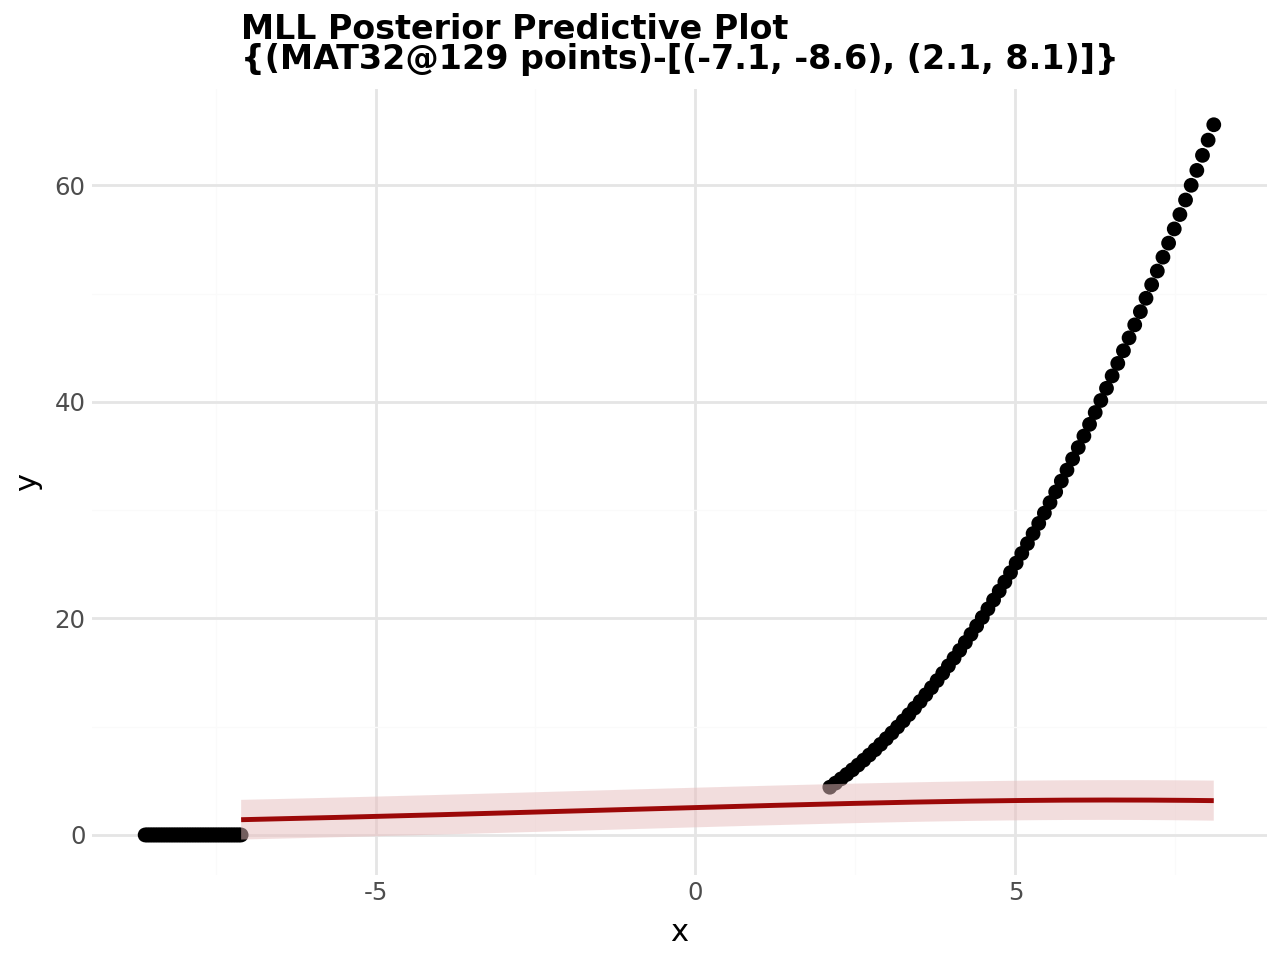

In [77]:
#plot_single_input_gp_posterior(train_x, train_y, train_x, predictive_distribution_MLL.mean, predictive_distribution_MLL.variance, show=True, return_fig=False)
posterior_ggplot(train_x, train_y, test_x, predictive_distribution_MLL.mean, predictive_distribution_MLL.variance, title=f"MLL Posterior Predictive Plot \n{{({kernel_name}@{len(train_x)} points)-{x_bounds}}}")

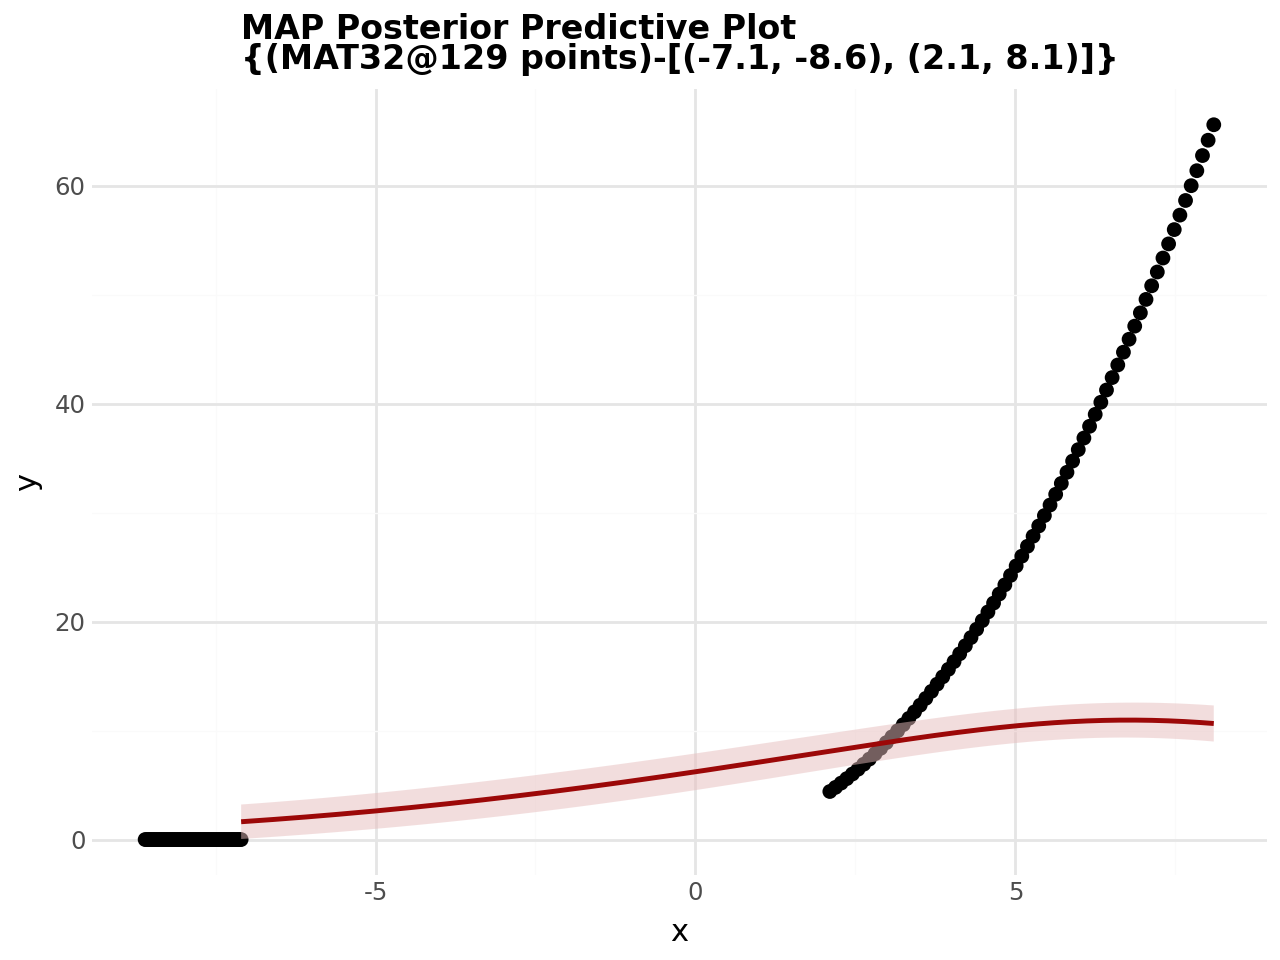

In [78]:
#plot_single_input_gp_posterior(train_x, train_y, train_x, predictive_distribution_MAP.mean, predictive_distribution_MAP.variance, show=True, return_fig=False)
posterior_ggplot(train_x, train_y, test_x, predictive_distribution_MAP.mean, predictive_distribution_MAP.variance, title=f"MAP Posterior Predictive Plot \n{{({kernel_name}@{len(train_x)} points)-{x_bounds}}}")

# Training params

In [79]:
map_train_par = list(model_MAP.named_parameters())
if hold:
    # Add this dataframe to the continuous dataframe and display the big one 
    if not "map_training_params" in globals():
        map_training_params = {} 
    # Add another column with the current model_evidences_df
    map_training_params[f"({kernel_name}@{len(train_x)} points)-{x_bounds}"] = map_train_par
else:
    map_training_params = map_train_par

map_training_params

{'(MAT52@129 points)-[(-7.1, -8.6), (2.1, 8.1)]': [('likelihood.noise_covar.raw_noise',
   Parameter containing:
   tensor([115.5060], requires_grad=True)),
  ('covar_module.raw_lengthscale',
   Parameter containing:
   tensor([[7.4440]], requires_grad=True))],
 '(MAT32@129 points)-[(-7.1, -8.6), (2.1, 8.1)]': [('likelihood.noise_covar.raw_noise',
   Parameter containing:
   tensor([115.7704], requires_grad=True)),
  ('covar_module.raw_lengthscale',
   Parameter containing:
   tensor([[8.0371]], requires_grad=True))]}

In [80]:
mll_train_par = list(model_MLL.named_parameters())
if hold:
    # Add this dataframe to the continuous dataframe and display the big one 
    if not "mll_training_params" in globals():
        mll_training_params = {} 
    # Add another column with the current model_evidences_df
    mll_training_params[f"({kernel_name}@{len(train_x)} points)-{x_bounds}"] = mll_train_par
else:
    mll_training_params = mll_train_par

mll_training_params

{'(MAT52@129 points)-[(-7.1, -8.6), (2.1, 8.1)]': [('likelihood.noise_covar.raw_noise',
   Parameter containing:
   tensor([535.8758], requires_grad=True)),
  ('covar_module.raw_lengthscale',
   Parameter containing:
   tensor([[11.0885]], requires_grad=True))],
 '(MAT32@129 points)-[(-7.1, -8.6), (2.1, 8.1)]': [('likelihood.noise_covar.raw_noise',
   Parameter containing:
   tensor([536.7544], requires_grad=True)),
  ('covar_module.raw_lengthscale',
   Parameter containing:
   tensor([[12.9157]], requires_grad=True))]}

In [81]:
model_MLL.train()
model_MAP.train()
model_MLL.likelihood.train()
model_MAP.likelihood.train()

GaussianLikelihood(
  (noise_covar): HomoskedasticNoise(
    (raw_noise_constraint): GreaterThan(1.000E-04)
  )
)

# Metrics

## Metrics plot helper

In [82]:
def horizontal_bar_chart(df, total_df, total_val, passed_title="", colors=None):
    g = (
        ggplot(df, mapping=aes(x="bar", y="value", fill="group"))
        + geom_col(width=.5)

        # dot for the grand total
        + geom_point(
            data=total_df,
            mapping=aes(x="bar", y="value"),
            colour="black",
            size=4,
            inherit_aes=False
        )

        # text inside each segment
        + geom_text(
            aes(label="value"),
            position=position_stack(vjust=0.5),
            colour="white",
            size=8
        )

        # total label next to the dot (nudge_y shifts it rightward after coord_flip)
        + geom_text(
            data=total_df.assign(label=np.round(total_val, 3)),
            mapping=aes(x="bar", y="value", label="label"),
            position=position_nudge(x=0.15),   # 5 % to the right
            va="center",
            ha="left",
            size=8,
            inherit_aes=False
        )

        + coord_flip()                          # horizontal orientation
        + labs(x="", y="value")
        + theme_minimal()
        + theme(figure_size=(6, 1.5))           # width 6 in, height 2.5 in
        + labs(title=f"{passed_title}")
    )
    if colors is not None:
        g += scale_fill_manual(values=colors) 
        # colours can be list or dict; plotnine handles both
    return g

## Metrics

In [83]:
neg_scaled_mll

tensor(4.6022, grad_fn=<NegBackward0>)

In [84]:
neg_scaled_map

tensor(5.8755, grad_fn=<SubBackward0>)

In [85]:
pos_unscaled_mll = -neg_scaled_mll*len(train_x)
pos_unscaled_map = -neg_scaled_map*len(train_x)

In [86]:
# Now the actual experiment starts
# UNscaled MAP and MLL
map_metric = MAP(logarithmic=True, scaling=False)
mll = MLL(logarithmic=True, scaling=False)
lap0 = Lap0(prior=model_parameter_prior)
lapA = LapAIC(prior=model_parameter_prior)
lapB = LapBIC(num_data=len(train_x), prior=model_parameter_prior)
aic = AIC()
bic = BIC(len(train_x))
nested_sampling = NestedSampling(model=model_MAP, prior=model_parameter_prior, store_full=False, logging=True, maxcall=1e+6, maxiter=1e+6)# print_progress=True, 

model_parameters_lap = [p for p in model_MAP.parameters() if p.requires_grad]

map_call = lambda : map_metric(model_MAP, likelihood_MAP, train_x, train_y, prior=model_parameter_prior, logging=True)
mll_call = lambda : mll(model_MLL, likelihood_MLL, train_x, train_y, logging=True)
lap0_call = lambda : lap0(pos_unscaled_map, model_parameters_lap, logging=True, model=model_MAP, use_finite_difference_hessian=True)
lapA_call = lambda: lapA(pos_unscaled_map, model_parameters_lap, logging=True, model=model_MAP, use_finite_difference_hessian=True)
lapB_call = lambda : lapB(pos_unscaled_map, model_parameters_lap, logging=True, model=model_MAP, use_finite_difference_hessian=True)
aic_call = lambda : aic(pos_unscaled_mll, len(model_parameters_lap), logging=True)
bic_call = lambda : bic(pos_unscaled_mll, len(model_parameters_lap), logging=True)
nested_sampling_call = lambda : nested_sampling(logging=True)

In [87]:
target_metrics = [map_metric, mll, lap0, lapA, lapB, aic, bic]
metric_calls = [map_call, mll_call, lap0_call, lapA_call, lapB_call, aic_call, bic_call]
if use_NS:
    target_metrics.append(nested_sampling)
    metric_calls.append(nested_sampling_call)


In [88]:
everything = [call_fkt() for call_fkt in metric_calls]
model_evidences = {str(metric): e[0] for metric, e in zip(target_metrics, everything)}
model_evidences["AIC"] = model_evidences["AIC"] * (-0.5)
model_evidences["BIC"] = model_evidences["BIC"] * (-0.5)
all_logs = {str(metric): e[1] for metric, e in zip(target_metrics, everything)}

/home/andreas/code/2025_LaplaceKernelSearch/src/laplace_model_selection/metrics.py:99: UserWarning: To copy construct from a tensor, it is recommended to use sourceTensor.clone().detach() or sourceTensor.clone().detach().requires_grad_(True), rather than torch.tensor(sourceTensor).


# Hessian EVs

In [89]:
if hold:
    # Add this dataframe to the continuous dataframe and display the big one 
    if not "Lap_logs" in globals():
        Lap_logs = {} 
    # Add another column with the current model_evidences_df
    Lap_logs[f"({kernel_name}@{len(train_x)} points)-{x_bounds}"] = all_logs["Lap0"] 
else:
    Lap_logs = all_logs["Lap0"]

Lap_logs

{'(MAT52@129 points)-[(-7.1, -8.6), (2.1, 8.1)]': {'Jacobian autograd': (tensor([4.4190e-08], grad_fn=<AddBackward0>),
   tensor([[9.4616e-08]], grad_fn=<AddBackward0>)),
  'Hessian autograd symmetrized': tensor([[ 0.0287, -0.0045],
          [-0.0045,  0.1738]]),
  'Hessian finite difference symmetrized': tensor([[ 0.0287, -0.0045],
          [-0.0045,  0.3713]]),
  'Hessian pre correction': tensor([[ 0.0287, -0.0045],
          [-0.0045,  0.3713]]),
  'num replaced': tensor(2),
  'eigenvectors Hessian pre correction': tensor([[-0.9999, -0.0130],
          [-0.0130,  0.9999]]),
  'Hessian post correction': tensor([[ 6.2832e+00,  1.3878e-17],
          [-1.3878e-17,  6.2832e+00]]),
  'constructed eigvals log': tensor([6.2832, 6.2832]),
  'neg MAP': tensor(757.2038, grad_fn=<NegBackward0>),
  'punish term': tensor(0.),
  'laplace without replacement': tensor(-753.0950, grad_fn=<AddBackward0>),
  'correction term': 0.0,
  'use finite differences': True,
  'model evidence approx': tensor(

In [90]:
if not torch.isclose(pos_unscaled_map, model_evidences["log MAP"], rtol=1e-3):
    print(pos_unscaled_map, model_evidences["log MAP"])
    raise ValueError("The MAP value does not match the computed value from the model.")

In [91]:
if not torch.isclose(pos_unscaled_mll, model_evidences["log ML"], rtol=1e-3):
    print(pos_unscaled_mll, model_evidences["log ML"])
    raise ValueError("The MAP value does not match the computed value from the model.")

In [92]:
color_palette = ["#fa8775",
"#ea5f94",
"#cd34b5",
"#9d02d7",
"#0000ff"]


## MLL logs plot

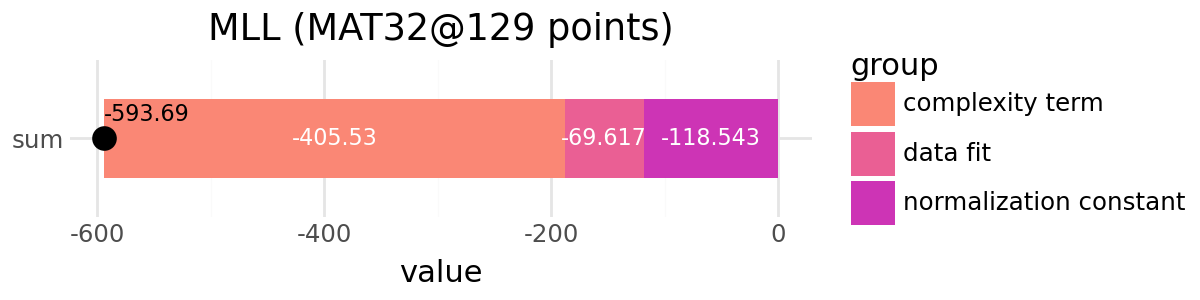

In [93]:
from plotnine import *
import pandas as pd
import numpy as np

# -----------------------------------------------------------------------
# scalar summands (rounded to 3 dp)
data_fit     = np.round(all_logs["log ML"]["data fit"].item(), 3)
complex_term = np.round(all_logs["log ML"]["complexity term"].item(), 3)
norm_const   = np.round(all_logs["log ML"]["normalization constant"].item(), 3)

# tidy data --------------------------------------------------------------
df = pd.DataFrame({
    "group": ["data fit", "complexity term", "normalization constant"],
    "value": [data_fit, complex_term, norm_const]
})
df["bar"] = "sum"                     # single (stacked) bar

# total for the dot & label ---------------------------------------------
total_val = df["value"].sum()
total_df  = pd.DataFrame({"bar": ["sum"], "value": [total_val]})

# -----------------------------------------------------------------------
# plot
# -----------------------------------------------------------------------
g = horizontal_bar_chart(df, total_df, total_val, passed_title = f"MLL ({kernel_name}@{len(train_x)} points)", colors=color_palette)
g.show()

## MAP logs plot

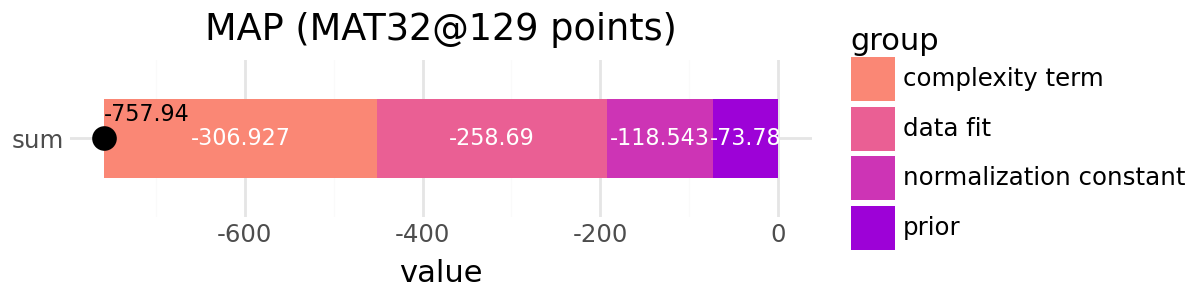

In [94]:
# -----------------------------------------------------------------------
# scalar summands (rounded to 3 dp)
prior_val    = np.round(all_logs["log MAP"]["prior_value"].item(), 3)
data_fit     = np.round(all_logs["log MAP"]["data fit"].item(), 3)
complex_term = np.round(all_logs["log MAP"]["complexity term"].item(), 3)
norm_const   = np.round(all_logs["log MAP"]["normalization constant"].item(), 3)

# tidy data --------------------------------------------------------------
df = pd.DataFrame({
    "group": ["prior", "data fit", "complexity term", "normalization constant"],
    "value": [prior_val, data_fit, complex_term, norm_const]
})
df["bar"] = "sum"                     # single (stacked) bar

# total for the dot & label ---------------------------------------------
total_val = df["value"].sum()
total_df  = pd.DataFrame({"bar": ["sum"], "value": [total_val]})

# -----------------------------------------------------------------------
# plot
# -----------------------------------------------------------------------
g = horizontal_bar_chart(df, total_df, total_val, passed_title = f"MAP ({kernel_name}@{len(train_x)} points)", colors=color_palette)
g.show()

## Laplace logs plot

### Lap

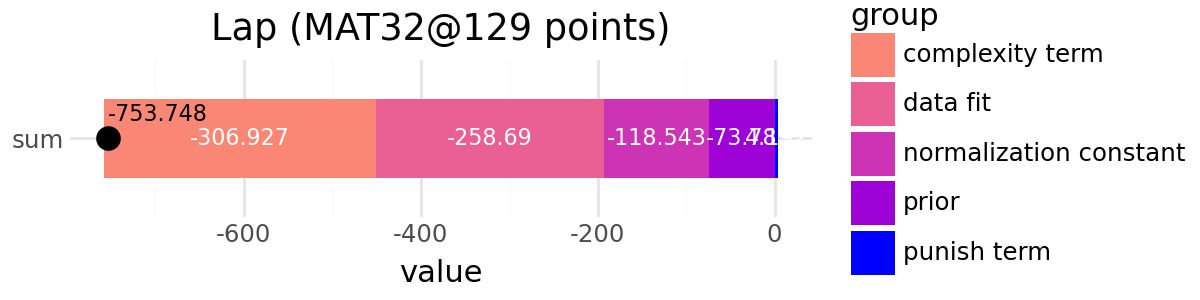

In [95]:

# -----------------------------------------------------------------------
Lap_val    = np.round(all_logs["Lap0"]["laplace without replacement"].item(), 3)
#all_logs["Lap0"]
# laplace without replacement
# punish term
# neg MAP



### Since Lap is MAP based, we use the information from MAP as well
prior_val    = np.round(all_logs["log MAP"]["prior_value"].item(), 3)
data_fit     = np.round(all_logs["log MAP"]["data fit"].item(), 3)
complex_term = np.round(all_logs["log MAP"]["complexity term"].item(), 3)
norm_const   = np.round(all_logs["log MAP"]["normalization constant"].item(), 3)

unknown_diff = np.round((Lap_val - (prior_val + data_fit + complex_term + norm_const)), 3)

# tidy data --------------------------------------------------------------
df = pd.DataFrame({
    "group": ["punish term", "prior", "data fit", "complexity term", "normalization constant"],
    "value": [unknown_diff, prior_val, data_fit, complex_term, norm_const]
})
df["bar"] = "sum"                     # single (stacked) bar

# total for the dot & label ---------------------------------------------
total_val = Lap_val#df["value"].sum()
total_df  = pd.DataFrame({"bar": ["sum"], "value": [total_val]})

horizontal_bar_chart(df, total_df, total_val, passed_title = f"Lap ({kernel_name}@{len(train_x)} points)", colors=color_palette)


### Lap0

In [96]:
def Lap_horizontal_plot_generator(name):

    # -----------------------------------------------------------------------
    Lap0_val    = np.round(model_evidences[name].item(), 3)
    Lap0_punish    = np.round(all_logs[name]["punish term"].item(), 3)
    #all_logs["Lap0"]
    # laplace without replacement
    # punish term
    # neg MAP



    ### Since Lap is MAP based, we use the information from MAP as well
    prior_val    = np.round(all_logs["log MAP"]["prior_value"].item(), 3)
    data_fit     = np.round(all_logs["log MAP"]["data fit"].item(), 3)
    complex_term = np.round(all_logs["log MAP"]["complexity term"].item(), 3)
    norm_const   = np.round(all_logs["log MAP"]["normalization constant"].item(), 3)

    unknown_diff = np.round((Lap0_val - Lap0_punish - (prior_val + data_fit + complex_term + norm_const)), 3)
    if unknown_diff > 0:
        print("SOMETHING IS FISHY")
        print(unknown_diff)

    # tidy data --------------------------------------------------------------
    df = pd.DataFrame({
        "group": ["punish term", "prior", "data fit", "complexity term", "normalization constant"],
        "value": [Lap0_punish, prior_val, data_fit, complex_term, norm_const]
    })
    df["bar"] = "sum"                     # single (stacked) bar

    # total for the dot & label ---------------------------------------------
    total_val = Lap0_val#df["value"].sum()
    total_df  = pd.DataFrame({"bar": ["sum"], "value": [total_val]})

    return horizontal_bar_chart(df, total_df, total_val, passed_title = f"{name} ({kernel_name}@{len(train_x)} points)", colors=color_palette)


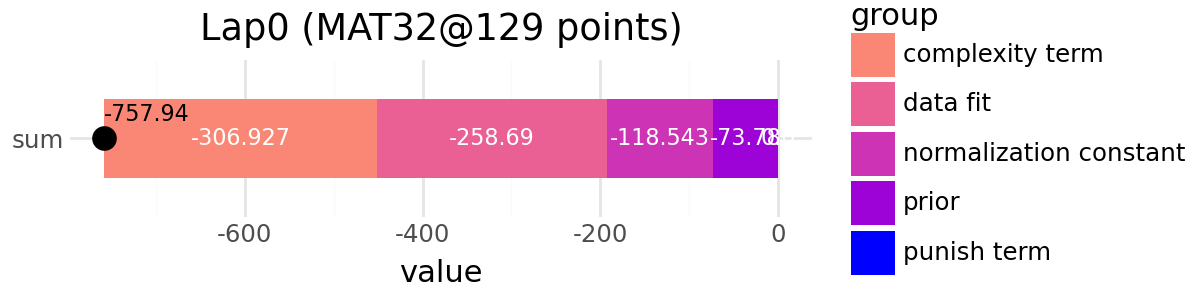

In [97]:
Lap_horizontal_plot_generator("Lap0")

### LapAIC

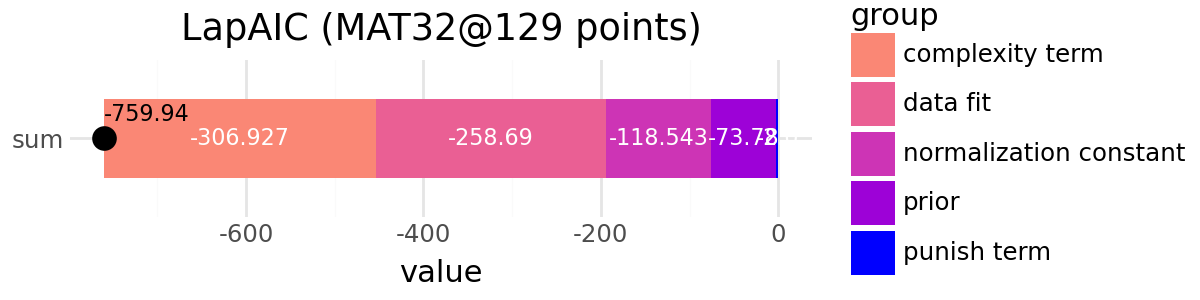

In [98]:
Lap_horizontal_plot_generator("LapAIC")

### LapBIC

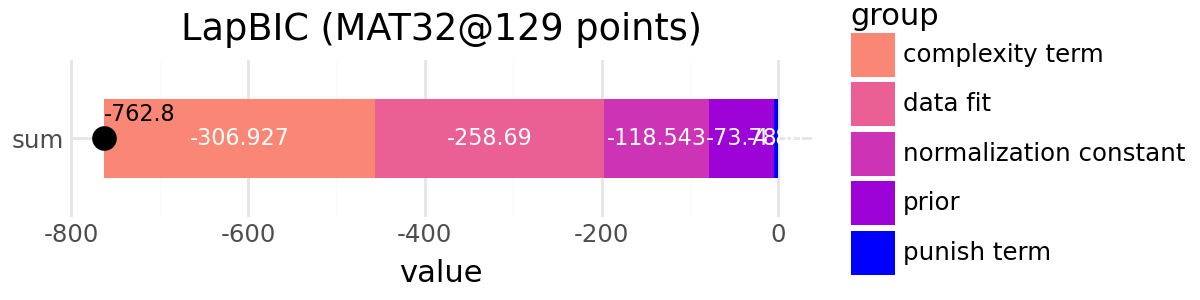

In [99]:
Lap_horizontal_plot_generator("LapBIC")

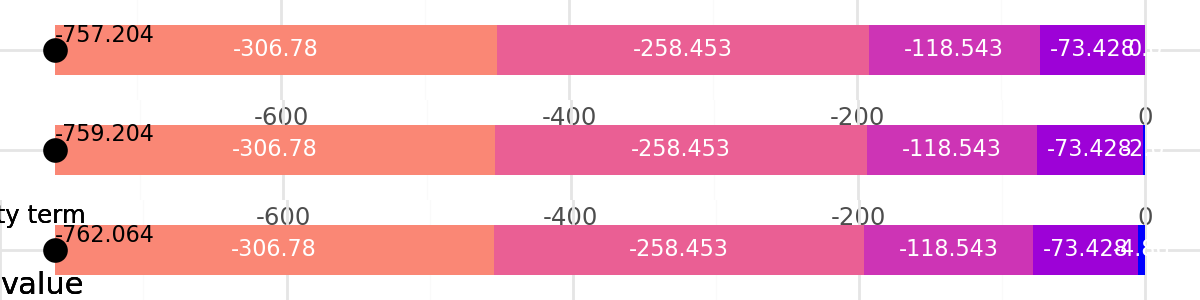

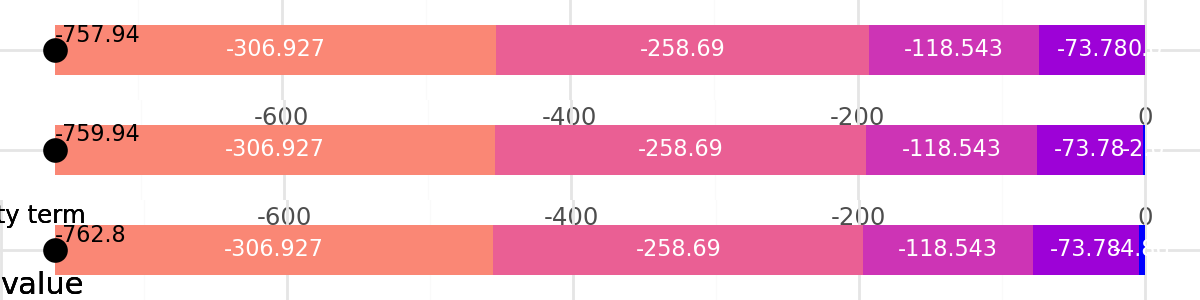

In [100]:
import operator
# Laps summary plot
hold = True
if hold:
    # Create a plot consisting of multiple rows of the plots
    if not "Lap_plots_all_runs" in locals():
        Lap_plots_all_runs = []
    Lap_plots_all_runs.append(reduce(operator.truediv, [Lap_horizontal_plot_generator("Lap0"), Lap_horizontal_plot_generator("LapAIC") , Lap_horizontal_plot_generator("LapBIC")]))
    g = grid_of(Lap_plots_all_runs, ncol=1)
    for g in Lap_plots_all_runs:
        display(g)
else:
    g = reduce(operator.truediv, [Lap_horizontal_plot_generator("Lap0") , Lap_horizontal_plot_generator("LapAIC") , Lap_horizontal_plot_generator("LapBIC")] )
    display(g)

## NS logs plot

# Result Summary

## Metric Table

In [101]:
# Print in a nice table all the model evidences in model_evidences
model_evidences_df = pd.DataFrame(model_evidences, index=[0])
model_evidences_df = model_evidences_df.T
column_name = f"({kernel_name}@{len(train_x)} points)-{x_bounds}"
model_evidences_df.columns = [column_name]
model_evidences_df[column_name] = model_evidences_df[column_name].apply(lambda x: np.round(x.item() if hasattr(x, "item") else x, 3))
model_evidences_df.index.name = "metric"
model_evidences_df.reset_index(inplace=True)




if hold:
    # Add this dataframe to the continuous dataframe and display the big one 
    if not "model_evidences_df_all_runs" in globals():
        model_evidences_df_all_runs = model_evidences_df
    else:
        # Add another column with the current model_evidences_df
        model_evidences_df_all_runs = pd.concat([model_evidences_df_all_runs, model_evidences_df[column_name]], axis=1)
    print(model_evidences_df_all_runs)
else:
    print(model_evidences_df.T)


    metric  (MAT52@129 points)-[(-7.1, -8.6), (2.1, 8.1)]  \
0  log MAP                                       -757.204   
1   log ML                                       -593.651   
2     Lap0                                       -757.204   
3   LapAIC                                       -759.204   
4   LapBIC                                       -762.064   
5      AIC                                       -595.651   
6      BIC                                       -598.511   

   (MAT32@129 points)-[(-7.1, -8.6), (2.1, 8.1)]  
0                                       -757.940  
1                                       -593.690  
2                                       -757.940  
3                                       -759.940  
4                                       -762.800  
5                                       -595.690  
6                                       -598.549  


In [102]:
print(model_evidences_df_all_runs.T.to_latex(float_format="%.3f"))

\begin{tabular}{llllllll}
\toprule
 & 0 & 1 & 2 & 3 & 4 & 5 & 6 \\
\midrule
metric & log MAP & log ML & Lap0 & LapAIC & LapBIC & AIC & BIC \\
(MAT52@129 points)-[(-7.1, -8.6), (2.1, 8.1)] & -757.204 & -593.651 & -757.204 & -759.204 & -762.064 & -595.651 & -598.511 \\
(MAT32@129 points)-[(-7.1, -8.6), (2.1, 8.1)] & -757.940 & -593.690 & -757.940 & -759.940 & -762.800 & -595.690 & -598.549 \\
\bottomrule
\end{tabular}



In [103]:
print(x_sq_steepness)
print(x_counts)

1.0
[60, 69]
